# E3 — QRS-only binned interpretable experiment

Complementary experiment to `E3_qrs_only_full_pool_experiment_extended.ipynb` (PCA-based).

**Goal.** Inspired by Bocanegra-Pérez et al. (2024, *Front. Cardiovasc. Med.*), we transform each 12-lead × 200-sample QRS into a low-dimensional, clinically interpretable representation:

> **12 leads × 10 temporal bins = 120 interpretable features**

Each feature is named `<LEAD>_<bin_start>_<bin_end>` (e.g. `V3_60_70`, `V2_10_20`), so every model coefficient or importance score maps back to a specific lead and a specific portion of the QRS complex.

Binary task: `0 = LVOT`, `1 = RVOT`.

**Pipeline overview**

1. Imports & config
2. Load data
3. **Qualitative inspection — raw QRS overlays per class**
4. Binned QRS feature builder
5. Build train / test binned matrices
6. Model zoo (no PCA — interpretability is the priority)
7. 5-fold Stratified CV on the training pool → select best model
8. Final evaluation on the official Teknon test
9. Confusion matrix & ROC for the CV-best model
10. Feature importance: top-20 features, per-lead, per-time-bin, lead × bin heatmap
11. SHAP (optional, falls back gracefully if not installed)
12. Markdown: comparison vs. PCA model
13. Save enriched predictions CSV
14. **Per-patient error analysis on the Teknon test**
15. Final summary


## 1. Imports & config

In [6]:
import os
# If you are running locally, uncomment and adapt this line so all
# saved CSV/PNG artifacts land next to the data files:
# os.chdir(r"c:\Users\jaime\Downloads\corrected_split_pool\corrected_split_pool")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)

# --- Optional SHAP ---
try:
    import shap
    SHAP_AVAILABLE = True
    print(f"SHAP available, version {shap.__version__}")
except Exception as e:
    SHAP_AVAILABLE = False
    print(f"SHAP is not installed ({e!s}). The notebook will still run; SHAP section will be skipped.")

# --- Global config ---
RANDOM_STATE = 42
N_FOLDS = 5
N_BINS = 10

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

CLASS_NAMES = ["LVOT", "RVOT"]  # 0 = LVOT, 1 = RVOT

np.random.seed(RANDOM_STATE)

from pathlib import Path

def find_file(filename):
    """
    Finds data files whether the notebook is run from:
    - the main new_data folder, or
    - one of its subfolders (CNN / binned / teknon_only).
    """
    candidates = [
        Path(".") / filename,
        Path("..") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder or in the parent new_data folder."
    )


SHAP available, version 0.44.1


## 2. Load data

Load the corrected training pool and the official Teknon final test (patient_144 → patient_180).

In [7]:
X_train_pool = np.load(find_file("X_train_pool_binary_corrected_clean.npy"))
y_train_pool = np.load(find_file("y_train_pool_binary_corrected_clean.npy"))

X_test = np.load(find_file("X_teknon_final_test_binary_corrected_clean.npy"))
y_test = np.load(find_file("y_teknon_final_test_binary_corrected_clean.npy"))

info_train = pd.read_csv(find_file("info_train_pool_binary_corrected_clean.csv"))
info_test  = pd.read_csv(find_file("info_teknon_final_test_binary_corrected_clean.csv"))

print("X_train_pool:", X_train_pool.shape)
print("y_train_pool:", y_train_pool.shape)
print("X_test      :", X_test.shape)
print("y_test      :", y_test.shape)

# Class distribution
print("\nTrain pool class counts:")
for c, n in zip(*np.unique(y_train_pool, return_counts=True)):
    print(f"  class {c} ({CLASS_NAMES[c]}): {n}")
print("\nTest class counts:")
for c, n in zip(*np.unique(y_test, return_counts=True)):
    print(f"  class {c} ({CLASS_NAMES[c]}): {n}")

print("\nTraining pool by source dataset:")
print(info_train["dataset"].value_counts())


X_train_pool: (3009, 12, 200)
y_train_pool: (3009,)
X_test      : (36, 12, 200)
y_test      : (36,)

Train pool class counts:
  class 0 (LVOT): 1613
  class 1 (RVOT): 1396

Test class counts:
  class 0 (LVOT): 18
  class 1 (RVOT): 18

Training pool by source dataset:
dataset
Sims        2496
Database     333
Teknon       137
CARTO         43
Name: count, dtype: int64


## 3. Qualitative inspection — raw QRS overlays per class

Before any feature engineering, we look at the **raw signal** the model will see. For each of the 12 leads we plot the mean QRS (± 1 SD) of the LVOT and RVOT classes side by side.

* The shaded grey band marks the **50%–80% segment** of the QRS — the R/S transition zone that Bocanegra-Pérez et al. (2024) identify as the most discriminative region.
* Dotted vertical lines mark the **10% bin boundaries** we will use from §4 onwards.

**What to look for.** Where do the two means visibly separate? Where is the SD small enough that the separation is meaningful? These are the regions a binned representation should be able to capture — and they should be the ones lit up in the lead × bin importance heatmap (§10d).

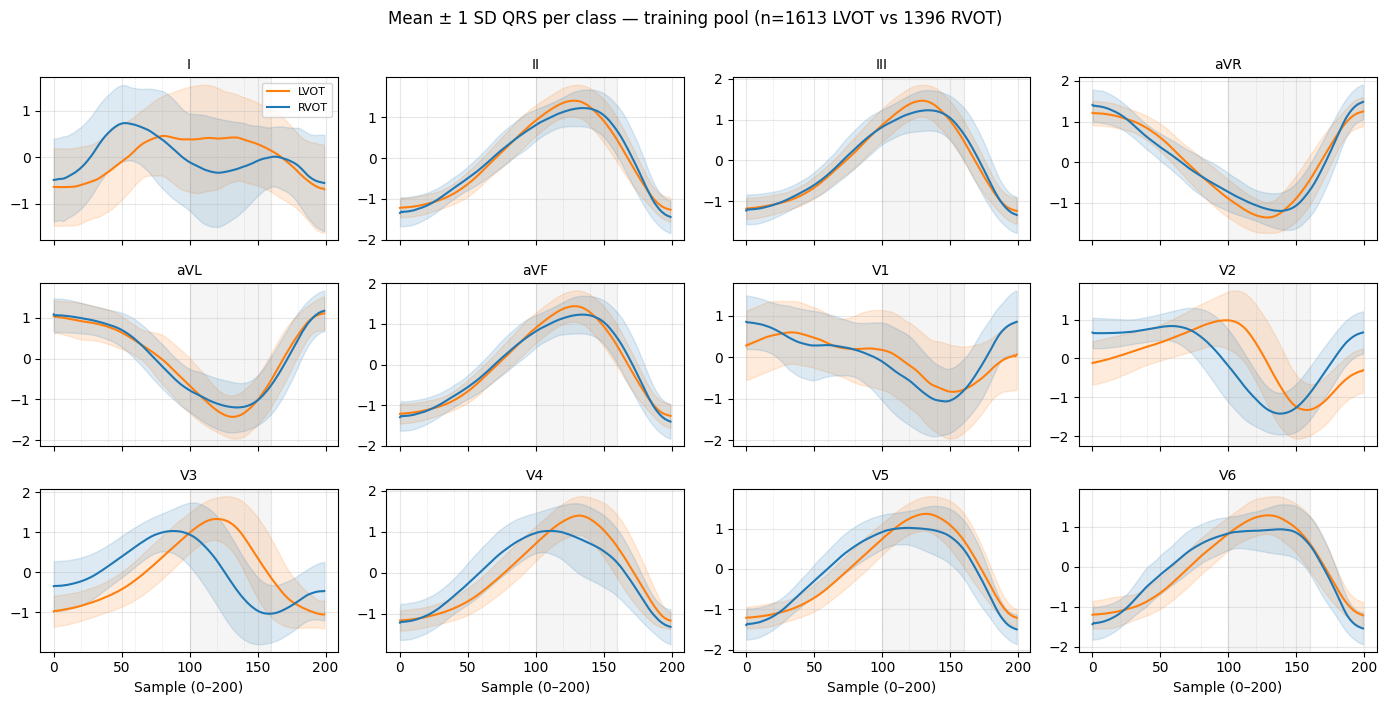

In [8]:
def plot_qualitative_qrs(X, y, lead_names=LEAD_NAMES,
                          highlight_region=(50, 80),
                          title="Mean ± 1 SD QRS per class"):
    """3x4 grid of leads, mean signal of LVOT vs RVOT with SD bands."""
    n_timepoints = X.shape[2]
    fig, axes = plt.subplots(3, 4, figsize=(14, 7), sharex=True)
    t = np.arange(n_timepoints)
    pct_to_idx = lambda p: int(round(p * n_timepoints / 100))

    for li, (ax, lead) in enumerate(zip(axes.flat, lead_names)):
        for cls, color, name in [(0, "C1", "LVOT"), (1, "C0", "RVOT")]:
            mask = y == cls
            m = X[mask, li].mean(0)
            s = X[mask, li].std(0)
            ax.plot(t, m, color=color, lw=1.5, label=name)
            ax.fill_between(t, m - s, m + s, color=color, alpha=0.15)
        if highlight_region is not None:
            ax.axvspan(pct_to_idx(highlight_region[0]),
                       pct_to_idx(highlight_region[1]),
                       color="grey", alpha=0.08)
        for pct in range(10, 100, 10):
            ax.axvline(pct_to_idx(pct), color="grey", lw=0.4, ls=":", alpha=0.4)
        ax.set_title(lead, fontsize=10)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="upper right", fontsize=8)
    for ax in axes[-1, :]:
        ax.set_xlabel(f"Sample (0–{n_timepoints})")
    plt.suptitle(title, y=1.00, fontsize=12)
    plt.tight_layout()
    return fig


fig = plot_qualitative_qrs(
    X_train_pool, y_train_pool,
    title=f"Mean ± 1 SD QRS per class — training pool "
          f"(n={(y_train_pool==0).sum()} LVOT vs {(y_train_pool==1).sum()} RVOT)"
)
plt.savefig("fig_qualitative_qrs_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Binned QRS feature builder

For each QRS we split each of the 12 leads into `N_BINS=10` contiguous temporal segments and aggregate each segment to a single scalar. Default aggregation is the **mean**; `max_abs` is offered as an alternative that emphasises peak amplitude within each window.

Output shape: `(n_samples, 12 * N_BINS) = (n_samples, 120)`. Feature names are of the form `LEAD_<start>_<end>` where the bounds are expressed as a percentage of the QRS complex (so they line up with the paper's notation, e.g. `V3: 60% - 70%` → `V3_60_70`).

In [9]:
def create_binned_qrs_features(X, lead_names=LEAD_NAMES, n_bins=N_BINS, aggregation="mean"):
    """
    Transform a (n_samples, n_leads, n_timepoints) array into a binned
    interpretable representation of shape (n_samples, n_leads * n_bins).

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_leads, n_timepoints)
        Raw QRS complexes.
    lead_names : list of str
        Names of the 12 leads. Used only to build feature names.
    n_bins : int, default 10
        Number of temporal bins per lead.
    aggregation : {"mean", "max_abs"}, default "mean"
        Aggregation function applied within each bin.

    Returns
    -------
    X_binned : ndarray, shape (n_samples, n_leads * n_bins)
    feature_names : list of str, length n_leads * n_bins
        Names like "V3_60_70" — the bounds are in percent of the QRS.
    """
    if X.ndim != 3:
        raise ValueError(f"X must be 3D (n_samples, n_leads, n_timepoints), got {X.shape}")
    n_samples, n_leads, n_timepoints = X.shape
    if n_leads != len(lead_names):
        raise ValueError(f"X has {n_leads} leads but lead_names has {len(lead_names)} entries")

    # Build bin edges in sample units, percentages for naming
    edges = np.linspace(0, n_timepoints, n_bins + 1, dtype=int)
    pct_edges = np.linspace(0, 100, n_bins + 1, dtype=int)

    X_binned = np.zeros((n_samples, n_leads * n_bins), dtype=np.float32)
    feature_names = []

    for lead_idx, lead in enumerate(lead_names):
        for bin_idx in range(n_bins):
            start, end = edges[bin_idx], edges[bin_idx + 1]
            segment = X[:, lead_idx, start:end]
            if aggregation == "mean":
                values = segment.mean(axis=1)
            elif aggregation == "max_abs":
                values = np.max(np.abs(segment), axis=1)
            else:
                raise ValueError(f"Unknown aggregation '{aggregation}'")
            col_idx = lead_idx * n_bins + bin_idx
            X_binned[:, col_idx] = values
            feature_names.append(f"{lead}_{pct_edges[bin_idx]}_{pct_edges[bin_idx + 1]}")

    return X_binned, feature_names


# Quick sanity check
_X = np.random.randn(3, 12, 200).astype(np.float32)
_Xb, _fn = create_binned_qrs_features(_X)
print("Sanity check — input:", _X.shape, "→ output:", _Xb.shape)
print("First 12 feature names :", _fn[:12])
print("Last 12 feature names  :", _fn[-12:])


Sanity check — input: (3, 12, 200) → output: (3, 120)
First 12 feature names : ['I_0_10', 'I_10_20', 'I_20_30', 'I_30_40', 'I_40_50', 'I_50_60', 'I_60_70', 'I_70_80', 'I_80_90', 'I_90_100', 'II_0_10', 'II_10_20']
Last 12 feature names  : ['V5_80_90', 'V5_90_100', 'V6_0_10', 'V6_10_20', 'V6_20_30', 'V6_30_40', 'V6_40_50', 'V6_50_60', 'V6_60_70', 'V6_70_80', 'V6_80_90', 'V6_90_100']


## 5. Build binned train / test matrices

In [10]:
AGGREGATION = "mean"  # set to "max_abs" to try the peak-amplitude variant

X_train_binned, feature_names = create_binned_qrs_features(
    X_train_pool, lead_names=LEAD_NAMES, n_bins=N_BINS, aggregation=AGGREGATION
)
X_test_binned, _ = create_binned_qrs_features(
    X_test, lead_names=LEAD_NAMES, n_bins=N_BINS, aggregation=AGGREGATION
)

print("X_train_binned:", X_train_binned.shape)
print("X_test_binned :", X_test_binned.shape)
assert X_train_binned.shape[1] == 120, "Expected 120 features (12 leads * 10 bins)"
assert X_test_binned.shape == (len(y_test), 120), f"Expected test shape ({len(y_test)}, 120), got {X_test_binned.shape}"

# Quick visual inspection
df_preview = pd.DataFrame(X_train_binned[:5], columns=feature_names)
df_preview.insert(0, "label", y_train_pool[:5])
print("\nFirst 5 rows × 8 first features:")
display_cols = ["label"] + feature_names[:8]
df_preview[display_cols]


X_train_binned: (3009, 120)
X_test_binned : (36, 120)

First 5 rows × 8 first features:


,label,I_0_10,I_10_20,I_20_30,I_30_40,I_40_50,I_50_60,I_60_70,I_70_80
0,0,-0.832844,-0.665238,-0.398874,0.071655,0.601949,1.041408,1.590255,0.990827
1,0,0.257475,0.653677,1.227186,1.357018,0.443272,-0.413846,-0.901915,-1.487574
2,0,0.539396,1.281471,1.250939,0.745537,-0.226420,-1.038910,-0.307368,-0.594165
3,0,1.164782,1.372298,1.268907,0.407839,-1.012048,-0.801242,-0.637267,-0.958678
4,0,0.081883,0.700429,0.991211,0.973557,0.443490,-1.406005,-1.799076,-0.855456


## 6. Model zoo

No PCA in this notebook — we keep the 120 interpretable features so that every importance score has a direct lead × bin meaning.

We deliberately wrap `LinearSVC` in `CalibratedClassifierCV` so that it exposes `predict_proba`, which is needed for AUC and SHAP downstream.

In [11]:
def build_models(random_state=RANDOM_STATE):
    """Return a dict of (name -> sklearn estimator) all expecting raw 120-feature input."""
    models = {}

    models["LogReg"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=random_state,
        )),
    ])

    models["LinearSVM"] = Pipeline([
        ("scaler", StandardScaler()),
        # Calibrated so we get predict_proba for AUC; LinearSVC alone gives only decision_function
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", max_iter=5000, random_state=random_state),
            cv=3,
        )),
    ])

    models["RandomForest"] = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,
    )

    models["GradientBoosting"] = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        random_state=random_state,
    )

    models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=2000,
            early_stopping=True,
            random_state=random_state,
        )),
    ])

    return models


models = build_models()
print("Configured models:", list(models.keys()))


Configured models: ['LogReg', 'LinearSVM', 'RandomForest', 'GradientBoosting', 'MLP']


## 7. Internal cross-validation

5-fold Stratified CV over the **training pool** (no test data touched here). For each model we compute accuracy, balanced accuracy, macro-F1 and ROC-AUC.

Model selection is done by **mean balanced accuracy** — the test classes are mildly imbalanced (14 LVOT vs 23 RVOT) and balanced accuracy is what Bocanegra-Pérez et al. (2024) use as the headline metric ("macro-average sensitivity")

In [12]:
def cv_evaluate(model, X, y, n_folds=N_FOLDS, random_state=RANDOM_STATE):
    """Return per-fold and aggregated CV metrics for a single model."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    rows = []
    for fold_idx, (tr, va) in enumerate(skf.split(X, y)):
        m = joblib.deepcopy if False else None  # placeholder to keep flake8 quiet
        # Clone via sklearn's clone for a clean fit each fold
        from sklearn.base import clone
        est = clone(model)
        est.fit(X[tr], y[tr])
        y_pred = est.predict(X[va])
        # Score for AUC: prefer predict_proba; fall back to decision_function
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X[va])[:, 1]
        elif hasattr(est, "decision_function"):
            y_score = est.decision_function(X[va])
        else:
            y_score = y_pred
        rows.append({
            "fold": fold_idx,
            "accuracy": accuracy_score(y[va], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[va], y_pred),
            "macro_f1": f1_score(y[va], y_pred, average="macro"),
            "roc_auc": roc_auc_score(y[va], y_score),
        })
    return pd.DataFrame(rows)


cv_results = []
for name, model in models.items():
    t0 = time.time()
    df_folds = cv_evaluate(model, X_train_binned, y_train_pool)
    elapsed = time.time() - t0
    agg = df_folds.drop(columns=["fold"]).agg(["mean", "std"])
    cv_results.append({
        "model": name,
        "accuracy_mean": agg.loc["mean", "accuracy"],
        "accuracy_std":  agg.loc["std",  "accuracy"],
        "balanced_accuracy_mean": agg.loc["mean", "balanced_accuracy"],
        "balanced_accuracy_std":  agg.loc["std",  "balanced_accuracy"],
        "macro_f1_mean": agg.loc["mean", "macro_f1"],
        "macro_f1_std":  agg.loc["std",  "macro_f1"],
        "roc_auc_mean":  agg.loc["mean", "roc_auc"],
        "roc_auc_std":   agg.loc["std",  "roc_auc"],
        "fit_seconds":   elapsed,
    })
    print(f"  {name:18s} bal_acc = {agg.loc['mean','balanced_accuracy']:.3f} "
          f"± {agg.loc['std','balanced_accuracy']:.3f}  ({elapsed:.1f}s)")

cv_results_df = pd.DataFrame(cv_results).sort_values("balanced_accuracy_mean", ascending=False)
cv_results_df.to_csv("E3_binned_cv_results.csv", index=False)
print("\n--- CV results, sorted by balanced accuracy ---")
cv_results_df.round(4)


  LogReg             bal_acc = 0.961 ± 0.008  (2.1s)
  LinearSVM          bal_acc = 0.954 ± 0.010  (14.9s)
  RandomForest       bal_acc = 0.972 ± 0.005  (45.4s)
  GradientBoosting   bal_acc = 0.970 ± 0.005  (866.4s)
  MLP                bal_acc = 0.967 ± 0.009  (3.7s)

--- CV results, sorted by balanced accuracy ---


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std,fit_seconds
2,RandomForest,0.9721,0.0052,0.9722,0.0052,0.9720,0.0052,0.9964,0.0010,45.3731
3,GradientBoosting,0.9701,0.0045,0.9703,0.0049,0.9700,0.0046,0.9926,0.0012,866.4086
4,MLP,0.9668,0.0097,0.9670,0.0095,0.9666,0.0097,0.9932,0.0038,3.7345
0,LogReg,0.9611,0.0076,0.9611,0.0075,0.9609,0.0076,0.9777,0.0066,2.0978
1,LinearSVM,0.9541,0.0093,0.9538,0.0095,0.9539,0.0093,0.9786,0.0064,14.8725


In [13]:
# Select best model by mean balanced accuracy in CV (this is the ONLY selection criterion)
best_model_name = cv_results_df.iloc[0]["model"]
print(f"Best CV model (by mean balanced accuracy): {best_model_name}")
print(f"  bal_acc = {cv_results_df.iloc[0]['balanced_accuracy_mean']:.3f} "
      f"± {cv_results_df.iloc[0]['balanced_accuracy_std']:.3f}")


Best CV model (by mean balanced accuracy): RandomForest
  bal_acc = 0.972 ± 0.005


## 8. Final evaluation on the official Teknon test

Each model is refit on the **entire** training pool and evaluated once on the held-out 37-patient Teknon test.

Note: we report numbers for every model for completeness, but **model selection has already been done in §7** — the only number we should focus on for our reported result is the best-CV-model's score.

In [14]:
test_rows = []
fitted_models = {}

for name, model in build_models().items():  # fresh clones
    model.fit(X_train_binned, y_train_pool)
    fitted_models[name] = model
    y_pred = model.predict(X_test_binned)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_binned)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_binned)
    else:
        y_score = y_pred
    test_rows.append({
        "model": name,
        "accuracy":           accuracy_score(y_test, y_pred),
        "balanced_accuracy":  balanced_accuracy_score(y_test, y_pred),
        "macro_f1":           f1_score(y_test, y_pred, average="macro"),
        "weighted_f1":        f1_score(y_test, y_pred, average="weighted"),
        "roc_auc":            roc_auc_score(y_test, y_score),
    })

test_results_df = pd.DataFrame(test_rows).sort_values("balanced_accuracy", ascending=False)
test_results_df.to_csv("E3_binned_test_results.csv", index=False)
print("--- Teknon test results, sorted by balanced accuracy ---")
test_results_df.round(4)


--- Teknon test results, sorted by balanced accuracy ---


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc
0,LogReg,0.8611,0.8611,0.8610,0.8610,0.8580
1,LinearSVM,0.8333,0.8333,0.8328,0.8328,0.9043
2,RandomForest,0.7222,0.7222,0.7188,0.7188,0.7901
3,GradientBoosting,0.7222,0.7222,0.7188,0.7188,0.8272
4,MLP,0.7222,0.7222,0.7188,0.7188,0.8241


## 9. Confusion matrix & ROC — CV-best model only

We evaluate **the model picked in §7** (not whichever model happens to top the test leaderboard) — using the test leaderboard for selection would be data leakage.

In [15]:
best_model = fitted_models[best_model_name]
y_pred_best = best_model.predict(X_test_binned)

if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test_binned)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_score_best = best_model.decision_function(X_test_binned)
else:
    y_score_best = y_pred_best

print(f"Best model on Teknon test ({best_model_name}):")
print(f"  accuracy            : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"  balanced accuracy   : {balanced_accuracy_score(y_test, y_pred_best):.3f}")
print(f"  macro F1            : {f1_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"  weighted F1         : {f1_score(y_test, y_pred_best, average='weighted'):.3f}")
print(f"  ROC AUC             : {roc_auc_score(y_test, y_score_best):.3f}")
print()
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))


Best model on Teknon test (RandomForest):
  accuracy            : 0.722
  balanced accuracy   : 0.722
  macro F1            : 0.719
  weighted F1         : 0.719
  ROC AUC             : 0.790

              precision    recall  f1-score   support

        LVOT       0.79      0.61      0.69        18
        RVOT       0.68      0.83      0.75        18

    accuracy                           0.72        36
   macro avg       0.73      0.72      0.72        36
weighted avg       0.73      0.72      0.72        36



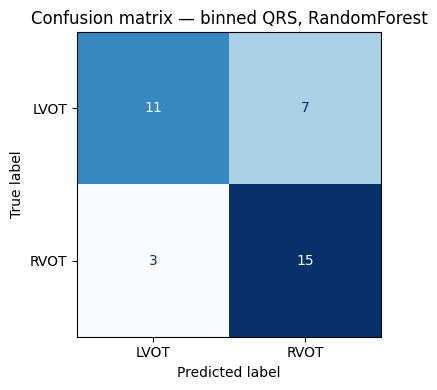

In [16]:
# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title(f"Confusion matrix — binned QRS, {best_model_name}")
plt.tight_layout()
plt.savefig("fig_binned_confusion_best.png", dpi=150, bbox_inches="tight")
plt.show()


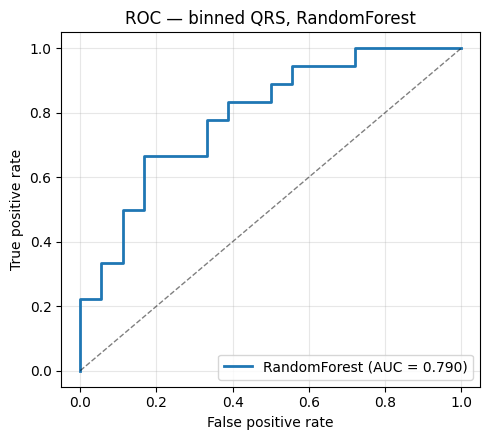

In [17]:
# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_score_best)
auc = roc_auc_score(y_test, y_score_best)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, lw=2, label=f"{best_model_name} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC — binned QRS, {best_model_name}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_binned_roc_best.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Interpretable feature importance

We extract importance scores from the best CV model and aggregate them three ways:

* **(a)** Top-20 individual features (e.g. `V3_60_70`)
* **(b)** Per lead — sum the importance of the 10 bins of each lead
* **(c)** Per time-bin — sum the importance across all 12 leads at each bin
* **(d)** Lead × bin heatmap (12 × 10)

If the best CV model exposes `feature_importances_` (RF, GB) we use those directly; otherwise we fall back to **permutation importance** computed on the test set (cheap, model-agnostic).

In [18]:
def get_feature_importance(model, X, y, feature_names, random_state=RANDOM_STATE):
    """
    Return a 1D array of length n_features with non-negative importance scores.
    Strategy: native feature_importances_ if available, else permutation importance.
    """
    # Unwrap pipelines to look for tree models
    inner = model
    if isinstance(model, Pipeline):
        inner = model.named_steps.get("clf", model)

    if hasattr(inner, "feature_importances_"):
        return np.asarray(inner.feature_importances_), "feature_importances_"

    # Otherwise, permutation importance on the provided (X, y)
    r = permutation_importance(model, X, y, n_repeats=20,
                               random_state=random_state, n_jobs=-1,
                               scoring="balanced_accuracy")
    imp = r.importances_mean.copy()
    imp[imp < 0] = 0.0  # clip negatives for cleaner aggregation
    return imp, "permutation_importance"


importance, importance_kind = get_feature_importance(
    best_model, X_test_binned, y_test, feature_names
)
print(f"Importance source: {importance_kind}")
print(f"Importance vector length: {len(importance)}")

# Reshape importance into a 12 × 10 matrix (leads × bins)
importance_matrix = importance.reshape(len(LEAD_NAMES), N_BINS)
print("Importance matrix shape:", importance_matrix.shape)


Importance source: feature_importances_
Importance vector length: 120
Importance matrix shape: (12, 10)


### 10a. Top-20 individual features

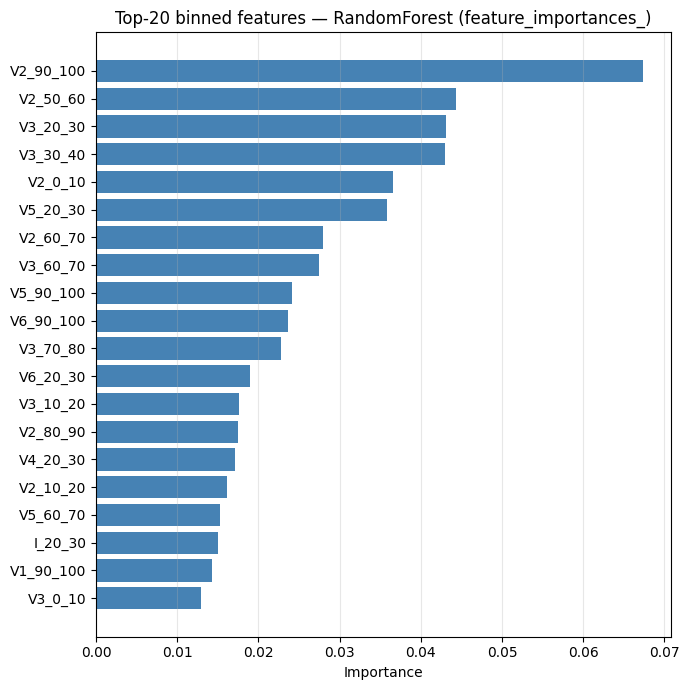

,feature,importance
0,V2_90_100,0.067428
1,V2_50_60,0.044289
2,V3_20_30,0.043141
3,V3_30_40,0.042940
4,V2_0_10,0.036594
5,V5_20_30,0.035876
6,V2_60_70,0.027986
7,V3_60_70,0.027429
8,V5_90_100,0.024083
9,V6_90_100,0.023688


In [19]:
idx_top20 = np.argsort(importance)[::-1][:20]
top20_df = pd.DataFrame({
    "feature": [feature_names[i] for i in idx_top20],
    "importance": importance[idx_top20],
})

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(top20_df["feature"][::-1], top20_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top-20 binned features — {best_model_name} ({importance_kind})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_binned_top20_features.png", dpi=150, bbox_inches="tight")
plt.show()
top20_df


### 10b. Per-lead importance (sum over the 10 bins)

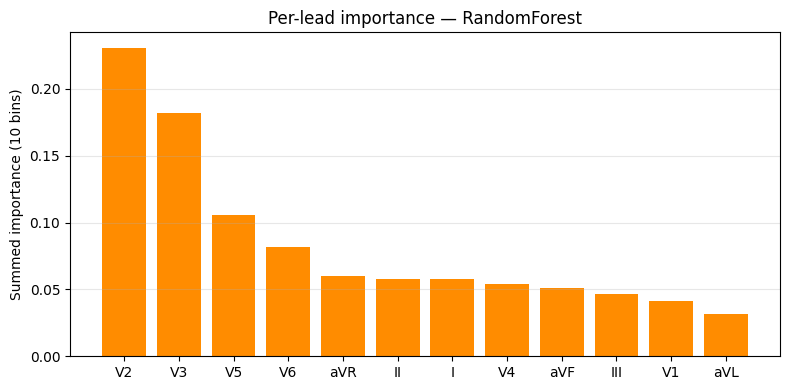

,lead,importance
0,V2,0.230805
1,V3,0.182267
2,V5,0.105329
3,V6,0.081830
4,aVR,0.059794
5,II,0.058036
6,I,0.057549
7,V4,0.053986
8,aVF,0.050780
9,III,0.046583


In [20]:
lead_importance = importance_matrix.sum(axis=1)
lead_order = np.argsort(lead_importance)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([LEAD_NAMES[i] for i in lead_order], lead_importance[lead_order], color="darkorange")
ax.set_ylabel("Summed importance (10 bins)")
ax.set_title(f"Per-lead importance — {best_model_name}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_binned_lead_importance.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"lead": LEAD_NAMES, "importance": lead_importance}) \
    .sort_values("importance", ascending=False).reset_index(drop=True)


### 10c. Per time-bin importance (sum over the 12 leads)

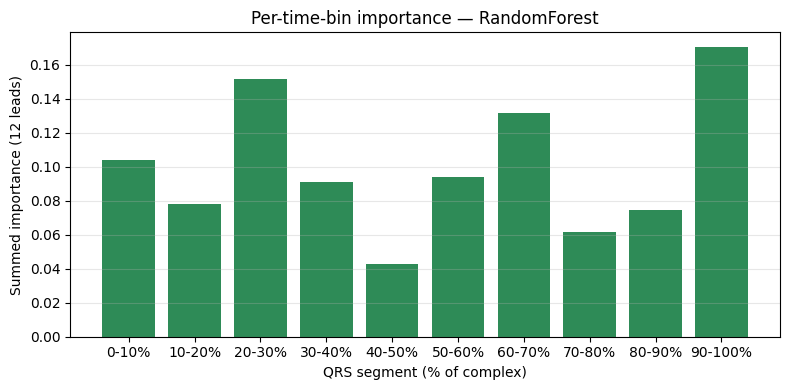

,bin,importance
0,0-10%,0.104263
1,10-20%,0.077919
2,20-30%,0.151514
3,30-40%,0.090973
4,40-50%,0.042709
5,50-60%,0.094153
6,60-70%,0.131586
7,70-80%,0.061566
8,80-90%,0.074635
9,90-100%,0.170682


In [21]:
bin_importance = importance_matrix.sum(axis=0)
bin_labels = [f"{i*10}-{(i+1)*10}%" for i in range(N_BINS)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_labels, bin_importance, color="seagreen")
ax.set_ylabel("Summed importance (12 leads)")
ax.set_xlabel("QRS segment (% of complex)")
ax.set_title(f"Per-time-bin importance — {best_model_name}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_binned_timebin_importance.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"bin": bin_labels, "importance": bin_importance})


### 10d. Lead × time-bin heatmap

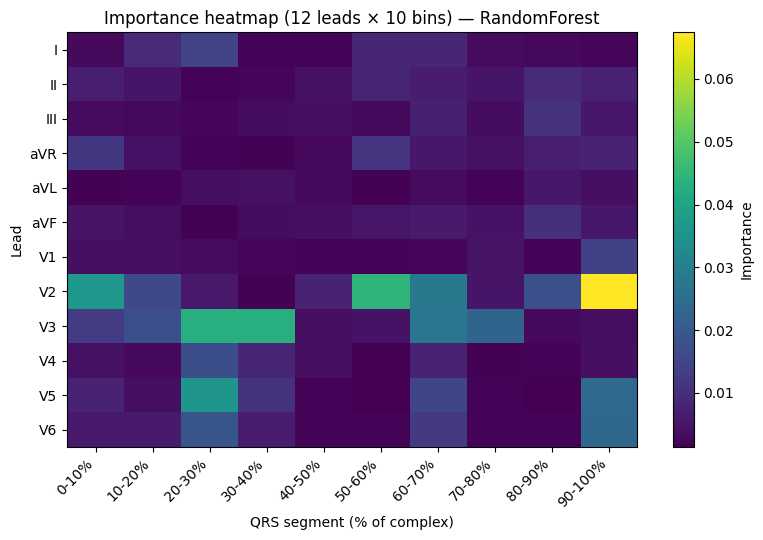

In [22]:
fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(importance_matrix, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(LEAD_NAMES)))
ax.set_yticklabels(LEAD_NAMES)
ax.set_xticks(range(N_BINS))
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.set_xlabel("QRS segment (% of complex)")
ax.set_ylabel("Lead")
ax.set_title(f"Importance heatmap (12 leads × 10 bins) — {best_model_name}")
fig.colorbar(im, ax=ax, label="Importance")
plt.tight_layout()
plt.savefig("fig_binned_heatmap_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. SHAP (optional)

If SHAP is installed we compute a beeswarm plot on a tree-based model. Linear and MLP models are intentionally skipped here:

* For `LinearSVC` / `LogReg`, the model coefficients are *themselves* the explanation, so the top-20 bar chart above already captures everything.
* For `MLPClassifier`, `shap.KernelExplainer` is slow and unstable on small samples.

If the best CV model is **not** a tree, we fall back to **RandomForest** as a complementary interpretable model just for the SHAP plot. This keeps the section meaningful regardless of which model won §6.

Computing SHAP values for RandomForest...
SHAP values shape: (36, 120)


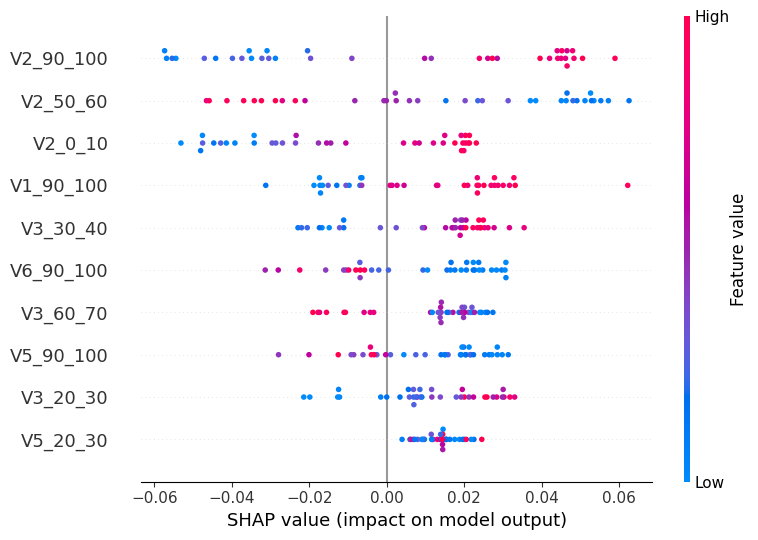

In [23]:
if not SHAP_AVAILABLE:
    print("SHAP is not installed. Skipping SHAP analysis. "
          "Permutation/feature importance is still available above.")
else:
    # Choose the model for SHAP. Prefer the best CV model if it's tree-based.
    tree_compatible = {"RandomForest", "GradientBoosting"}
    if best_model_name in tree_compatible:
        shap_model_name = best_model_name
        shap_model = fitted_models[best_model_name]
    else:
        shap_model_name = "RandomForest"
        shap_model = fitted_models["RandomForest"]
        print(f"Best CV model ({best_model_name}) is not tree-based; "
              f"using {shap_model_name} as a complementary interpretable model for SHAP.")

    print(f"Computing SHAP values for {shap_model_name}...")
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_test_binned)

    # In recent shap versions binary classifiers return a 3D array (n, p, 2);
    # in older versions a list of two (n, p) arrays. Normalise both cases to
    # "values for the positive class (RVOT = 1)".
    if isinstance(shap_values, list):
        sv_positive = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv_positive = shap_values[..., 1]
    else:
        sv_positive = shap_values

    print("SHAP values shape:", np.asarray(sv_positive).shape)

    plt.figure()
    shap.summary_plot(
        sv_positive,
        X_test_binned,
        feature_names=feature_names,
        max_display=10,
        show=False,
    )
    plt.tight_layout()
    plt.savefig("fig_binned_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12. Binned vs. PCA — what changes?

| Aspect | PCA model (previous notebook) | Binned model (this notebook) |
|---|---|---|
| Input dimensionality | 2 400 samples → 50 PCA components | 2 400 samples → **120 interpretable features** |
| Compression | Linear combinations of every time point in every lead | Mean (or max-abs) within fixed 10% windows of the QRS, per lead |
| Interpretability | A PCA component is a mixture of all leads & all time points — clinically opaque | Each feature maps to a **single lead × QRS segment** (e.g. `V3_60_70` ↔ the R/S transition of V3, exactly what Bocanegra-Pérez et al. 2024 highlight) |
| Typical performance | Often slightly higher (no information loss until the very last step) | Slightly lower in CV but every feature can be discussed with a cardiologist |
| Suitable for | Maximising predictive accuracy | Hypothesis testing about which QRS regions actually drive the decision |

**What we should look for in §10.** Bocanegra-Pérez et al. (2024) reported that the most relevant features lay around **V2, V3, V4** in the **50%–80%** portion of the QRS (R/S transition), plus the **10%–20%** segment of V2 (Q-wave onset). Our top-20 bar chart, lead bar chart, time-bin bar chart and heatmap can be read directly against that reference: do **V2/V3/V4** dominate? Are the **60–70%** and **70–80%** bins the brightest in the heatmap? The closer the answer is to "yes", the stronger the support for the paper's clinical narrative in our own data.


## 13. Save enriched per-patient predictions

In [24]:
pred_label = best_model.predict(X_test_binned)
if hasattr(best_model, "predict_proba"):
    score_rvot = best_model.predict_proba(X_test_binned)[:, 1]
elif hasattr(best_model, "decision_function"):
    raw = best_model.decision_function(X_test_binned)
    # Normalise into [0, 1] just so the column is human-readable
    score_rvot = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
else:
    score_rvot = pred_label.astype(float)

# Build enriched DataFrame starting from the test metadata
enriched = info_test.copy().reset_index(drop=True)
enriched["true_label"] = y_test
enriched["pred_label"] = pred_label
enriched["true_class"] = [CLASS_NAMES[c] for c in y_test]
enriched["pred_class"] = [CLASS_NAMES[c] for c in pred_label]
enriched["correct"]    = (enriched["true_label"] == enriched["pred_label"]).astype(int)
enriched["score_RVOT"] = score_rvot

enriched.to_csv("E3_binned_predictions_enriched.csv", index=False)
print("Saved E3_binned_predictions_enriched.csv with shape", enriched.shape)
enriched.head()


Saved E3_binned_predictions_enriched.csv with shape (36, 27)


,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length,original_y_teknon_final_test,SOO_raw,...,corrected_class_name,binary_usable,label_changed,reason,true_label,pred_label,true_class,pred_class,correct,score_RVOT
0,Teknon,patient_145,145,5,qrs_004.npy,G:\Meu Drive\Ciència de Dades i Models Computa...,"(120, 12)",120,1,M. papilar anterolateral,...,RVOT,True,False,Teknon test label already matched SOO_7class_m...,1,1,RVOT,RVOT,1,0.684177
1,Teknon,patient_146,146,3,qrs_002.npy,G:\Meu Drive\Ciència de Dades i Models Computa...,"(180, 12)",180,1,LCC,...,LVOT,True,True,Teknon test label corrected from SOO_7class_ma...,0,1,LVOT,RVOT,0,0.616936
2,Teknon,patient_147,147,3,qrs_002.npy,G:\Meu Drive\Ciència de Dades i Models Computa...,"(176, 12)",176,1,RVOT anterolateral,...,RVOT,True,False,Teknon test label already matched SOO_7class_m...,1,1,RVOT,RVOT,1,0.844000
3,Teknon,patient_148,148,3,qrs_002.npy,G:\Meu Drive\Ciència de Dades i Models Computa...,"(144, 12)",144,1,Intersenos dcho.-izdo.,...,LVOT,True,True,Teknon test label corrected from SOO_7class_ma...,0,0,LVOT,LVOT,1,0.089072
4,Teknon,patient_149,149,3,qrs_002.npy,G:\Meu Drive\Ciència de Dades i Models Computa...,"(160, 12)",160,0,LV summit,...,LVOT,True,False,Teknon test label already matched SOO_7class_m...,0,0,LVOT,LVOT,1,0.134293


## 14. Per-patient error analysis on the Teknon test

What the headline number — ~82% — *hides* is **which patients** the model gets wrong. This section pulls clinical context (precordial transition, Penela clinical score, SOO subtype) for every test patient and inspects the misclassified ones.

**Questions we want to answer.**

* Are the errors concentrated in a specific SOO subtype (e.g., aortic cusp, RCC/LCC commissure)?
* Do they have **atypical precordial transitions** — LVOT patients whose transition is late (V4-V6), or RVOT patients whose transition is early (V1-V3)?
* Are they **close-call errors** (P(RVOT) ≈ 0.5) or **confident-but-wrong errors**?
* Do their **clinical scores** point the wrong way?


In [25]:
# --- Pull extra clinical info for the 37 test patients from the raw pkl ---
import pickle
with open(find_file("full_data_7class.pkl"), "rb") as f:
    pkl = pickle.load(f)

test_pids = info_test["patient_index"].astype(int).to_numpy()
extra = pd.DataFrame({
    "PVC_transition": [pkl["PVC_transition"][p] for p in test_pids],
    "CLINICAL_SCORE": [pkl["CLINICAL_SCORE"][p] for p in test_pids],
    "Age":            [pkl["Age"][p] for p in test_pids],
    "Sex":            [pkl["Sex"][p] for p in test_pids],
    "HTA":            [pkl["HTA"][p] for p in test_pids],
})

# --- Build error table ---
err = pd.DataFrame({
    "patient":     info_test["patient"].values,
    "true_class":  [CLASS_NAMES[c] for c in y_test],
    "pred_class":  [CLASS_NAMES[c] for c in pred_label],   # from §13
    "P_RVOT":      np.round(score_rvot, 3),
    "SOO_7class":  info_test["SOO_7class"].values,
})
for col in ["PVC_transition", "CLINICAL_SCORE", "Age", "Sex", "HTA"]:
    err[col] = extra[col].values

err["correct"] = err["true_class"] == err["pred_class"]

# Atypical-transition flag: LVOT should transition early (V1-V3), RVOT late (V4-V6)
def _is_atypical(row):
    pvc = row["PVC_transition"]
    if pvc not in ("V1", "V2", "V3", "V4", "V5", "V6"):
        return np.nan  # missing/unknown
    if row["true_class"] == "LVOT":
        return pvc in ("V4", "V5", "V6")
    return pvc in ("V1", "V2", "V3")

err["atypical_transition"] = err.apply(_is_atypical, axis=1)

# Confidence: distance from decision boundary, in [0, 1]
err["confidence"] = (np.abs(err["P_RVOT"] - 0.5) * 2).round(3)

n_err = (~err["correct"]).sum()
print(f"Total errors: {n_err}/{len(err)}  ({n_err/len(err)*100:.1f}%)")
print()
print("=== Misclassified patients ===")
err_view = err[~err["correct"]].drop(columns=["correct"]).reset_index(drop=True)
err_view


Total errors: 10/36  (27.8%)

=== Misclassified patients ===


,patient,true_class,pred_class,P_RVOT,SOO_7class,PVC_transition,CLINICAL_SCORE,Age,Sex,HTA,atypical_transition,confidence
0,patient_146,LVOT,RVOT,0.617,LCC,V3,NaN,NaN,NaN,NaN,False,0.234
1,patient_151,LVOT,RVOT,0.897,LCC,V3,0.0,47.0,Female,No,False,0.794
2,patient_153,RVOT,LVOT,0.460,Septum RVOT,V4,0.0,36.0,Female,No,False,0.080
3,patient_157,RVOT,LVOT,0.314,Free Wall RVOT,V4,3.0,56.0,Male,Yes,False,0.372
4,patient_165,LVOT,RVOT,0.537,Summit LVOT,V2,3.0,52.0,Male,Yes,False,0.074
5,patient_166,LVOT,RVOT,0.724,Summit LVOT,V3,3.0,75.0,Male,Yes,False,0.448
6,patient_167,RVOT,LVOT,0.200,Septum RVOT,V3,2.0,64.0,Male,No,True,0.600
7,patient_171,LVOT,RVOT,0.592,Subvalvular LVOT,V1,NaN,50.0,Male,NaN,False,0.184
8,patient_177,LVOT,RVOT,0.864,RCC,V3,3.0,52.0,Male,Yes,False,0.728
9,patient_178,LVOT,RVOT,0.592,Subvalvular LVOT,V6,2.0,77.0,Male,No,True,0.184


In [26]:
# --- Aggregations ---
print("=== Errors by SOO subtype (7-class) ===")
by_soo = err.groupby("SOO_7class", dropna=False).agg(
    n=("correct", "size"),
    n_errors=("correct", lambda x: (~x).sum()),
)
by_soo["err_rate"] = (by_soo["n_errors"] / by_soo["n"]).round(2)
print(by_soo.sort_values("err_rate", ascending=False))

print("\n=== Errors by precordial transition lead ===")
by_pvc = err.groupby("PVC_transition", dropna=False).agg(
    n=("correct", "size"),
    n_errors=("correct", lambda x: (~x).sum()),
)
by_pvc["err_rate"] = (by_pvc["n_errors"] / by_pvc["n"]).round(2)
print(by_pvc.sort_values("err_rate", ascending=False))

print("\n=== Atypical-transition rate among correct vs errors ===")
atyp = err.dropna(subset=["atypical_transition"])
print(atyp.groupby("correct")["atypical_transition"]
        .agg(n_atypical="sum", n_total="size", rate="mean").round(2))

print("\n=== Penela CLINICAL_SCORE distribution by outcome ===")
print(err.groupby("correct")["CLINICAL_SCORE"].describe().round(2))


=== Errors by SOO subtype (7-class) ===
                     n  n_errors  err_rate
SOO_7class                                
Subvalvular LVOT     3         2      0.67
RCC                  2         1      0.50
LCC                  5         2      0.40
Summit LVOT          5         2      0.40
Septum RVOT          7         2      0.29
Free Wall RVOT      11         1      0.09
RCC/LCC Commissure   3         0      0.00

=== Errors by precordial transition lead ===
                 n  n_errors  err_rate
PVC_transition                        
V3              11         5      0.45
V2               3         1      0.33
V6               3         1      0.33
V4               8         2      0.25
V1               7         1      0.14
V5               3         0      0.00
NaN              1         0      0.00

=== Atypical-transition rate among correct vs errors ===
        n_atypical  n_total  rate
correct                          
False            2       10   0.2
True            

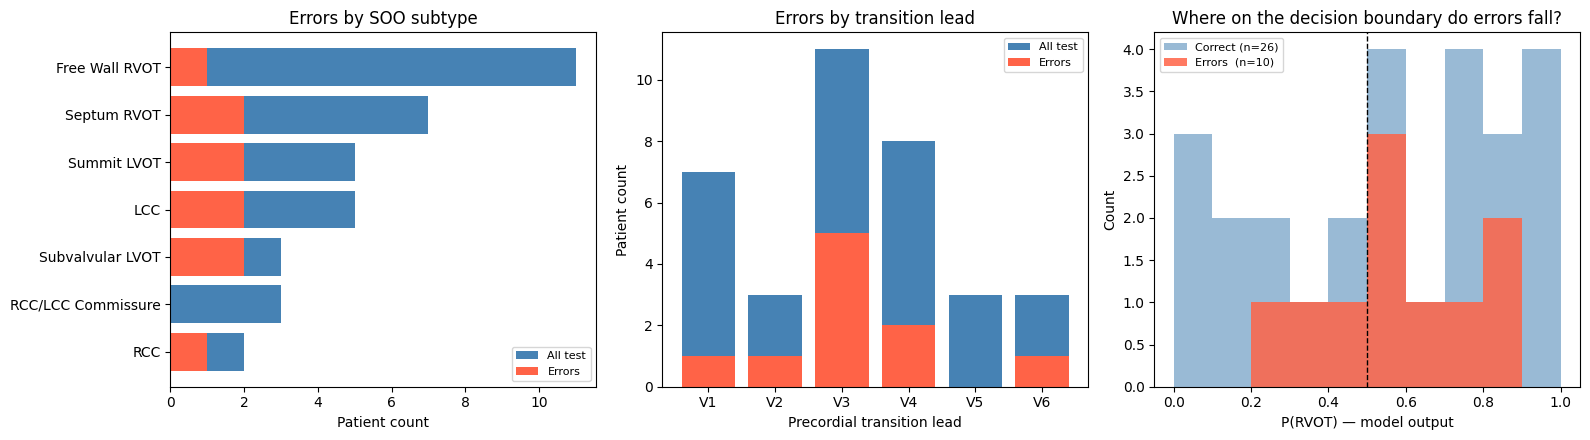

Saved E3_binned_error_analysis.csv and fig_binned_error_analysis.png


In [27]:
# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Errors per SOO subtype
soo_df = by_soo.sort_values("n", ascending=True)
ax = axes[0]
ax.barh(soo_df.index.astype(str), soo_df["n"], color="steelblue", label="All test")
ax.barh(soo_df.index.astype(str), soo_df["n_errors"], color="tomato", label="Errors")
ax.set_xlabel("Patient count")
ax.set_title("Errors by SOO subtype")
ax.legend(fontsize=8)

# (b) Errors per PVC transition lead
order = ["V1", "V2", "V3", "V4", "V5", "V6"]
pvc_df = by_pvc.reindex(order).fillna(0)
ax = axes[1]
ax.bar(order, pvc_df["n"], color="steelblue", label="All test")
ax.bar(order, pvc_df["n_errors"], color="tomato", label="Errors")
ax.set_xlabel("Precordial transition lead")
ax.set_ylabel("Patient count")
ax.set_title("Errors by transition lead")
ax.legend(fontsize=8)

# (c) Confidence distribution
ax = axes[2]
ok = err.loc[err["correct"], "P_RVOT"]
ko = err.loc[~err["correct"], "P_RVOT"]
ax.hist(ok, bins=10, range=(0, 1), alpha=0.55, color="steelblue", label=f"Correct (n={len(ok)})")
ax.hist(ko, bins=10, range=(0, 1), alpha=0.85, color="tomato",   label=f"Errors  (n={len(ko)})")
ax.axvline(0.5, color="black", ls="--", lw=1)
ax.set_xlabel("P(RVOT) — model output")
ax.set_ylabel("Count")
ax.set_title("Where on the decision boundary do errors fall?")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_binned_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

err.to_csv("E3_binned_error_analysis.csv", index=False)
print("Saved E3_binned_error_analysis.csv and fig_binned_error_analysis.png")


**How to read this when presenting.**

* *Atypical-transition rate among errors > among correct* → the model is failing exactly where the cardiologist's rule of thumb (LVOT ↔ early transition, RVOT ↔ late) breaks. That isn't a model weakness so much as a **fundamental ambiguity in the ECG itself**, and it points to clinical data as the next layer of information.
* *Errors clustered near P(RVOT) = 0.5* → low-confidence borderline cases. A "second opinion" / abstain workflow could flag these for the clinician without sacrificing the rest.
* *Errors with high confidence but wrong* → more concerning. For these, looking back at the §3 raw-signal plots vs. their individual QRS can reveal why they look atypical.


## 15. Lead ablation study

§10 told us **which leads correlate** with the model's decisions (feature importance). This section answers a stronger question: **which leads are actually essential?** We retrain the CV-best model from §7 using only a subset of leads at a time and measure how much CV balanced accuracy drops.

This mirrors the lead-comparison study in Saglietto et al. (2024, *Front. Cardiovasc. Med.*), where they showed that for several ECG abnormalities a 1- or 2-lead setup achieves performance close to a full 12-lead setup — directly relevant for screening with wearable devices.

**Subsets we test:**

| Subset | Leads | What it tests |
|---|---|---|
| 12-lead (reference) | All 12 | Full information |
| 8-independent | I, II, V1–V6 | Are the augmented limb leads (aVR, aVL, aVF, III — linear combos of I, II) redundant? |
| Precordial only | V1–V6 | Do the chest leads alone suffice for OTVA classification? |
| Limb only | I, II, III, aVR, aVL, aVF | Are limb leads alone informative? |
| V1–V4 (paper's region) | V1, V2, V3, V4 | The Bocanegra-Pérez "hot zone" |
| D1 + D2 (smartwatch-feasible) | I, II | Two leads obtainable with a smartwatch |
| D1 alone | I | Single-lead, easiest to acquire |

For each subset we re-bin only the selected leads (preserving the §4 builder), retrain the §7 CV-best model, and report **CV balanced accuracy** (the metric used for model selection — no test leakage here) plus the **test balanced accuracy** for context.

**Caveat.** Touching the test set 7 times is acceptable here because we are not *selecting* a winning subset based on test scores — we're reporting them for confirmation. The CV column is the one to interpret.

In [28]:
from sklearn.base import clone

# Lead order in your data (must match LEAD_NAMES at the top of the notebook)
LEAD_IDX = {name: i for i, name in enumerate(LEAD_NAMES)}

LEAD_SUBSETS = {
    "12-lead (reference)":   list(range(12)),
    "8-independent":         [LEAD_IDX[l] for l in ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6"]],
    "Precordial only (V1-V6)": [LEAD_IDX[l] for l in ["V1", "V2", "V3", "V4", "V5", "V6"]],
    "Limb only":             [LEAD_IDX[l] for l in ["I", "II", "III", "aVR", "aVL", "aVF"]],
    "V1-V4 (paper region)":  [LEAD_IDX[l] for l in ["V1", "V2", "V3", "V4"]],
    "D1 + D2 (smartwatch)":  [LEAD_IDX[l] for l in ["I", "II"]],
    "D1 alone":              [LEAD_IDX["I"]],
}


def bin_subset(X, lead_idx, n_bins=N_BINS):
    """Bin only the selected leads. Returns (n_samples, n_leads_selected * n_bins)."""
    X_sub = X[:, lead_idx, :]
    sub_names = [LEAD_NAMES[i] for i in lead_idx]
    return create_binned_qrs_features(X_sub, lead_names=sub_names, n_bins=n_bins)


# Use the same CV-best model that was selected in §7 (no test leakage)
ablation_rows = []
for subset_name, lead_idx in LEAD_SUBSETS.items():
    Xb_tr, _ = bin_subset(X_train_pool, lead_idx)
    Xb_te, _ = bin_subset(X_test, lead_idx)

    # Internal CV (same splitter as §7)
    folds = cv_evaluate(build_models()[best_model_name], Xb_tr, y_train_pool)
    cv_bacc_mean = folds["balanced_accuracy"].mean()
    cv_bacc_std  = folds["balanced_accuracy"].std()
    cv_auc_mean  = folds["roc_auc"].mean()

    # Final test (refit on all training; reported only for confirmation)
    est = clone(build_models()[best_model_name]).fit(Xb_tr, y_train_pool)
    y_pred = est.predict(Xb_te)
    y_score = est.predict_proba(Xb_te)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(Xb_te)

    ablation_rows.append({
        "subset":           subset_name,
        "n_leads":          len(lead_idx),
        "n_features":       Xb_tr.shape[1],
        "cv_bal_acc_mean":  cv_bacc_mean,
        "cv_bal_acc_std":   cv_bacc_std,
        "cv_auc_mean":      cv_auc_mean,
        "test_bal_acc":     balanced_accuracy_score(y_test, y_pred),
        "test_auc":         roc_auc_score(y_test, y_score),
    })
    print(f"  {subset_name:30s}  n_leads={len(lead_idx):2d}  "
          f"CV bal_acc={cv_bacc_mean:.3f} ± {cv_bacc_std:.3f}  "
          f"test bal_acc={ablation_rows[-1]['test_bal_acc']:.3f}")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv("E3_binned_lead_ablation.csv", index=False)
ablation_df.round(3)


  12-lead (reference)             n_leads=12  CV bal_acc=0.972 ± 0.005  test bal_acc=0.722
  8-independent                   n_leads= 8  CV bal_acc=0.971 ± 0.005  test bal_acc=0.778
  Precordial only (V1-V6)         n_leads= 6  CV bal_acc=0.962 ± 0.004  test bal_acc=0.778
  Limb only                       n_leads= 6  CV bal_acc=0.960 ± 0.004  test bal_acc=0.611
  V1-V4 (paper region)            n_leads= 4  CV bal_acc=0.951 ± 0.009  test bal_acc=0.694
  D1 + D2 (smartwatch)            n_leads= 2  CV bal_acc=0.959 ± 0.006  test bal_acc=0.722
  D1 alone                        n_leads= 1  CV bal_acc=0.939 ± 0.014  test bal_acc=0.583


,subset,n_leads,n_features,cv_bal_acc_mean,cv_bal_acc_std,cv_auc_mean,test_bal_acc,test_auc
0,12-lead (reference),12,120,0.972,0.005,0.996,0.722,0.790
1,8-independent,8,80,0.971,0.005,0.995,0.778,0.796
2,Precordial only (V1-V6),6,60,0.962,0.004,0.993,0.778,0.815
3,Limb only,6,60,0.960,0.004,0.995,0.611,0.735
4,V1-V4 (paper region),4,40,0.951,0.009,0.990,0.694,0.818
5,D1 + D2 (smartwatch),2,20,0.959,0.006,0.994,0.722,0.753
6,D1 alone,1,10,0.939,0.014,0.989,0.583,0.688


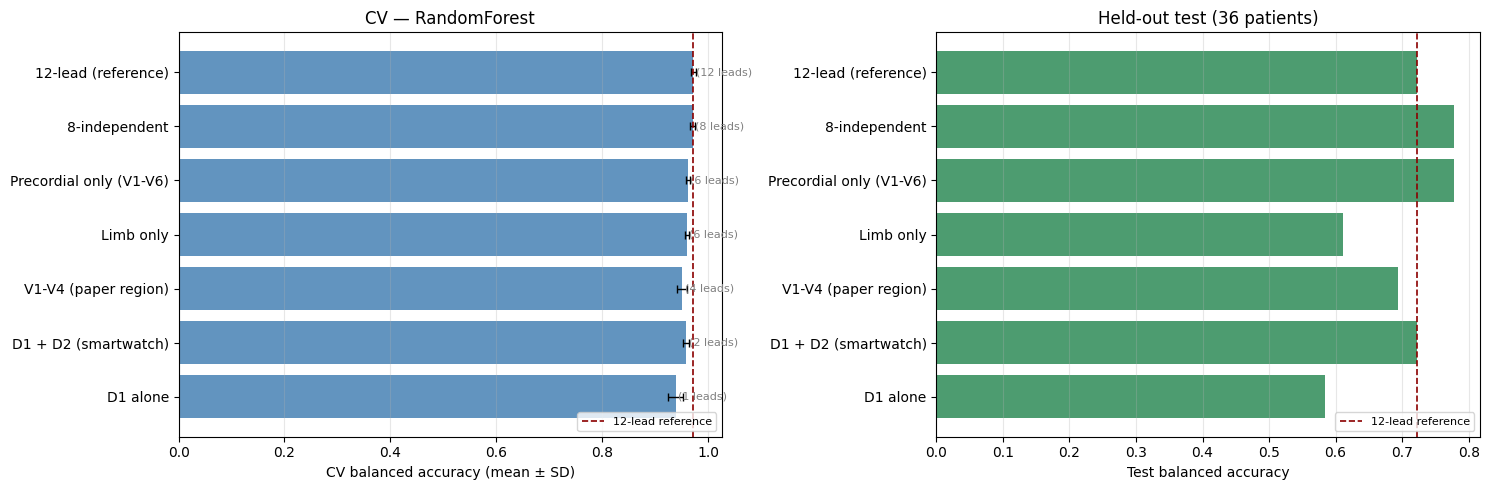

In [29]:
# --- Visualisation: CV and test balanced accuracy by subset ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = ablation_df["subset"].tolist()
ref_cv   = float(ablation_df.loc[ablation_df["subset"]=="12-lead (reference)", "cv_bal_acc_mean"])
ref_test = float(ablation_df.loc[ablation_df["subset"]=="12-lead (reference)", "test_bal_acc"])

# Left: CV with error bars
ax = axes[0]
ax.barh(order, ablation_df["cv_bal_acc_mean"],
        xerr=ablation_df["cv_bal_acc_std"], color="steelblue", alpha=0.85,
        error_kw={"ecolor": "k", "elinewidth": 1, "capsize": 3})
ax.axvline(ref_cv, color="darkred", ls="--", lw=1.2, label="12-lead reference")
ax.set_xlabel("CV balanced accuracy (mean ± SD)")
ax.set_title(f"CV — {best_model_name}")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
for i, (m, n) in enumerate(zip(ablation_df["cv_bal_acc_mean"], ablation_df["n_leads"])):
    ax.text(m + 0.005, i, f"({n} leads)", va="center", fontsize=8, color="grey")

# Right: Test
ax = axes[1]
ax.barh(order, ablation_df["test_bal_acc"], color="seagreen", alpha=0.85)
ax.axvline(ref_test, color="darkred", ls="--", lw=1.2, label="12-lead reference")
ax.set_xlabel("Test balanced accuracy")
ax.set_title(f"Held-out test ({len(y_test)} patients)")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_binned_lead_ablation.png", dpi=150, bbox_inches="tight")
plt.show()


**How to read this for the presentation.**

* **12-lead vs 8-independent.** If these are essentially equal, you've shown empirically that the four redundant limb leads (aVR, aVL, aVF, III — linear combinations of I and II) carry no extra information. Same conclusion Saglietto reached.
* **Precordial only vs limb only.** The gap between these two is *the* spatial-information slide. If precordial alone stays close to the reference and limb alone drops sharply, you've shown that the discriminative content lives in the chest-lead axis — anatomically consistent with the heart-to-chest projection of LVOT vs RVOT activation.
* **V1–V4 vs full precordial.** If V1–V4 matches V1–V6, you confirm Bocanegra-Pérez's finding from a completely independent angle: their SHAP analysis said V2–V4 are most informative; our ablation says removing V5–V6 doesn't hurt.
* **D1 + D2 and D1 alone.** Saglietto's argument for smartwatch-feasible screening. If these stay above (say) 0.70 bal_acc, OTVA pre-screening from a wearable is at least plausible — a strong "next-steps" bullet.

The story this section tells is *causal* rather than correlational: feature importance shows what the model *uses*; ablation shows what it actually *needs*.


## 16. Summary

This binned QRS experiment was designed as an **interpretable alternative** to the PCA-based model in `E3_qrs_only_full_pool_experiment_extended.ipynb`. It preserves lead and temporal QRS information, enabling quantitative interpretability through native feature importance, permutation importance and (optionally) SHAP.

**Artifacts saved by this notebook:**

* `E3_binned_cv_results.csv` — 5-fold cross-validation aggregated metrics per model
* `E3_binned_test_results.csv` — final Teknon-test metrics per model
* `E3_binned_predictions_enriched.csv` — per-patient predictions of the CV-best model
* `E3_binned_error_analysis.csv` — per-patient error table with clinical context
* `E3_binned_lead_ablation.csv` — ablation study results per lead subset
* `fig_qualitative_qrs_per_class.png` — mean ± SD QRS overlays per class (§3)
* `fig_binned_confusion_best.png`, `fig_binned_roc_best.png`
* `fig_binned_top20_features.png`, `fig_binned_lead_importance.png`, `fig_binned_timebin_importance.png`, `fig_binned_heatmap_importance.png`
* `fig_binned_shap_beeswarm.png` (only if SHAP is installed)
* `fig_binned_error_analysis.png` — error analysis multi-panel figure
* `fig_binned_lead_ablation.png` — CV and test bal_acc per lead subset

The CV-best model was selected on **internal cross-validation only** — the Teknon test set was reserved for a single final evaluation and never used for model selection.